In [28]:
import sys
sys.path.append("..")
sys.path.append("../api")

from api.AirbnbRemoteData import AirbnbRemoteData

berlin_listings_url = "https://data.insideairbnb.com/germany/be/berlin/2025-09-23/visualisations/listings.csv"
munich_listing_url = "https://data.insideairbnb.com/germany/bv/munich/2025-09-27/visualisations/listings.csv"

airbnb_fetcher = AirbnbRemoteData(berlin_listings_url, munich_listing_url)
airbnb_fetcher.fetch_data()

In [29]:
merged_df = airbnb_fetcher.get_combined_data()
if merged_df is not None:
    print(f"Successfully merged!")
    display(merged_df.head(500))
else:
    print("Merge failed. Check if the CSVs share a common column name (like 'id' or 'listing_id').")

Successfully merged!


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,city
0,3176,Fabulous Flat in great Location,3718,Britta,Pankow,Prenzlauer Berg Südwest,52.53471,13.41810,Entire home/apt,105.0,63,150,2025-08-09,0.76,1,140,2,First name and Last name: Nicolas Krotz <br/> ...,Berlin
1,9991,Geourgeous flat - outstanding views,33852,Philipp,Pankow,Prenzlauer Berg Südwest,52.53269,13.41805,Entire home/apt,135.0,6,7,2020-01-04,0.06,1,241,0,03/Z/RA/003410-18,Berlin
2,14325,Studio Apartment in Prenzlauer Berg,55531,Chris + Oliver,Pankow,Prenzlauer Berg Nordwest,52.54813,13.40366,Entire home/apt,75.0,150,26,2023-11-30,0.14,4,168,0,NaN,Berlin
3,17904,Beautiful Kreuzberg studio - 3 months minimum,68997,Matthias,Neukölln,Reuterstraße,52.49419,13.42166,Entire home/apt,32.0,93,298,2025-09-02,1.57,1,72,1,NaN,Berlin
4,20858,Designer Loft in Berlin Mitte,71331,Marc,Pankow,Prenzlauer Berg Südwest,52.53711,13.40888,Entire home/apt,202.0,3,140,2025-07-16,0.89,1,253,4,03/Z/RA/009767-24,Berlin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2137277,Modern + Renovated + Cool Kreuzberg,10692949,Suites And More,Friedrichshain-Kreuzberg,Tempelhofer Vorstadt,52.48980,13.41917,Entire home/apt,76.0,2,392,2025-08-29,2.83,3,232,31,First name and Last name: Magdalena Rynkar <br...,Berlin
496,2140695,Cozy Apartment in the vibrant heart of Berlin,4314868,Katharina,Pankow,Prenzlauer Berg Nordwest,52.54845,13.40299,Entire home/apt,63.0,92,74,2022-09-30,0.53,1,343,0,NaN,Berlin
497,2147777,Moabit apartment,10962834,Katharina,Mitte,Moabit West,52.53494,13.34055,Entire home/apt,73.0,2,301,2025-09-21,2.37,1,327,36,01/Z/ZA/006223-16,Berlin
498,2154488,4th floor on the Island,10986253,Oliver,Tempelhof - Schöneberg,Schöneberg-Süd,52.48348,13.36133,Private room,49.0,3,136,2025-08-29,0.99,1,107,15,07/Z/AZ/019980-25,Berlin


In [30]:
# the columns need to keep for analysis:price 
columns_to_keep = [
    'price',
    'room_type',
    'neighbourhood','city',
    'minimum_nights',
    'number_of_reviews','reviews_per_month','availability_365'
]
merged_df = merged_df[columns_to_keep]
merged_df

,price,room_type,neighbourhood,city,minimum_nights,number_of_reviews,reviews_per_month,availability_365
0,105.0,Entire home/apt,Prenzlauer Berg Südwest,Berlin,63,150,0.76,140
1,135.0,Entire home/apt,Prenzlauer Berg Südwest,Berlin,6,7,0.06,241
2,75.0,Entire home/apt,Prenzlauer Berg Nordwest,Berlin,150,26,0.14,168
3,32.0,Entire home/apt,Reuterstraße,Berlin,93,298,1.57,72
4,202.0,Entire home/apt,Prenzlauer Berg Südwest,Berlin,3,140,0.89,253
...,...,...,...,...,...,...,...,...
22543,427.0,Entire home/apt,Neuhausen-Nymphenburg,Munich,1,0,NaN,17
22544,152.0,Entire home/apt,Ludwigsvorstadt-Isarvorstadt,Munich,1,0,NaN,150
22545,200.0,Private room,Ludwigsvorstadt-Isarvorstadt,Munich,1,0,NaN,1
22546,120.0,Private room,Schwabing-Freimann,Munich,1,0,NaN,364


<Axes: ylabel='Frequency'>

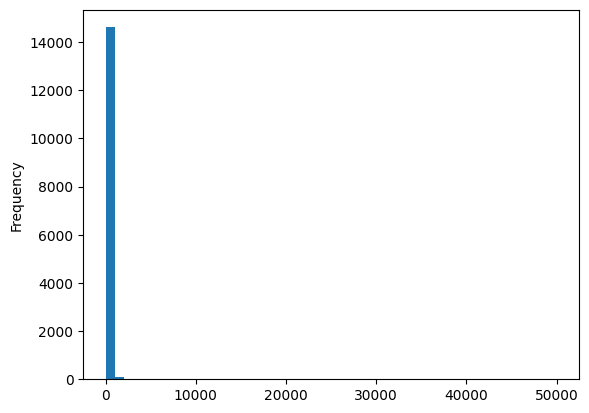

In [31]:
## Cleaning nas
df1=merged_df
df1.isnull().sum()
(df1.isnull().sum() / len(df1)) * 100
df2 = df1.dropna(subset=["price"]) # droping according to price
(df2.isnull().sum() / len(df2)) * 100

## Dealing with duplicates ################
df2.duplicated().sum()
df3 = df2.drop_duplicates()
df3.duplicated().sum()

## plotting price ###################
import matplotlib.pyplot as plt
df3["price"].plot(kind="hist", bins=50)
#df3[df3["price"] < 1000]["price"].plot(kind="hist", bins=50) 

<Axes: ylabel='Frequency'>

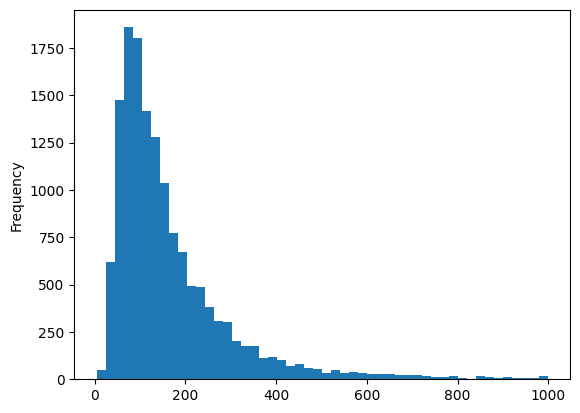

In [32]:
df3[df3["price"] < 1000]["price"].plot(kind="hist", bins=50)

In [33]:
df3["revenue"] = df3["minimum_nights"]* df3["price"]
#df3['revenue'] = df3['minimum_nights'].astype(int) * df3['price'].astype(float)
df3["revenue"] = df3["revenue"].round(2)

In [34]:
df_berlin = df3[(df3['city'] == 'Berlin') & (df3['price'] < 1000)].copy()

berlin_revenue = df_berlin.groupby(['neighbourhood', 'room_type'], as_index=False)['revenue'].sum()

berlin_revenue = berlin_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)
berlin_revenue["revenue"] = berlin_revenue["revenue"].round(2)
berlin_revenue

,neighbourhood,room_type,revenue
0,Alexanderplatz,Entire home/apt,2008392.0
1,Brunnenstr. Süd,Entire home/apt,1147360.0
2,Frankfurter Allee Süd FK,Entire home/apt,1127724.0
3,Tempelhofer Vorstadt,Entire home/apt,912365.0
4,Prenzlauer Berg Südwest,Entire home/apt,771116.0
...,...,...,...
302,Otto-Suhr-Allee,Shared room,50.0
303,Kantstraße,Shared room,48.0
304,Neu-Hohenschönhausen Süd,Entire home/apt,45.0
305,Gropiusstadt,Private room,37.0


In [35]:
df_berlin = df3[(df3['city'] == 'Berlin') & (df3['price'] < 1000)].copy()

berlin_revenue = df_berlin.groupby(['neighbourhood', 'room_type'], as_index=False)['revenue'].mean()

berlin_revenue = berlin_revenue.sort_values(by='revenue', ascending=False)
berlin_revenue = berlin_revenue.reset_index(drop=True)
berlin_revenue["revenue"] = berlin_revenue["revenue"].round(2)
berlin_revenue

,neighbourhood,room_type,revenue
0,Westend,Hotel room,74520.00
1,Heerstraße Nord,Entire home/apt,6745.50
2,Schmargendorf,Entire home/apt,6637.45
3,Müggelheim,Private room,6440.00
4,Hellersdorf-Nord,Private room,6067.33
...,...,...,...
302,Gropiusstadt,Private room,37.00
303,Tempelhofer Vorstadt,Shared room,33.29
304,Reuterstraße,Shared room,31.00
305,Schöneberg-Nord,Shared room,30.25


In [36]:
df_munich = df3[(df3['city'] == 'Munich') & (df3['price'] < 1000)].copy()

munich_revenue = df_munich.groupby(['neighbourhood', 'room_type'], as_index=False)['revenue'].mean()

munich_revenue = munich_revenue.sort_values(by='revenue', ascending=False)
munich_revenue = munich_revenue.reset_index(drop=True)
munich_revenue["revenue"] = munich_revenue["revenue"].round(2)
munich_revenue

,neighbourhood,room_type,revenue
0,Maxvorstadt,Private room,2799.67
1,Altstadt-Lehel,Entire home/apt,1929.83
2,Hadern,Entire home/apt,1856.18
3,Au-Haidhausen,Entire home/apt,1519.79
4,Schwabing-West,Entire home/apt,1512.70
...,...,...,...
62,Thalkirchen-Obersendling-Forstenried-Fürstenri...,Shared room,84.00
63,Bogenhausen,Shared room,64.00
64,Schwabing-West,Shared room,63.00
65,Feldmoching-Hasenbergl,Shared room,48.00


/var/folders/3b/rk4wlpz91b550937x0t31krc0000gn/T/ipykernel_4221/1262899304.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=room_type_summary, x='room_type', y='revenue', palette='viridis')


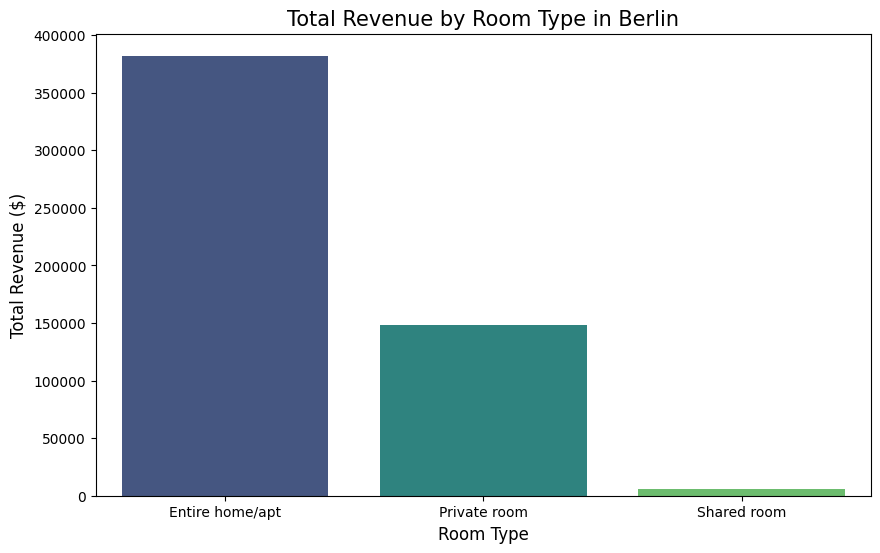

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

room_type_summary = berlin_revenue[berlin_revenue['room_type'] != 'Hotel room'].groupby('room_type', as_index=False)['revenue'].sum()

room_type_summary = room_type_summary.sort_values(by='revenue', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=room_type_summary, x='room_type', y='revenue', palette='viridis')

plt.title('Total Revenue by Room Type in Berlin', fontsize=15)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

plt.show()

/var/folders/3b/rk4wlpz91b550937x0t31krc0000gn/T/ipykernel_4221/556655121.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=room_type_summary, x='room_type', y='revenue', palette='viridis')


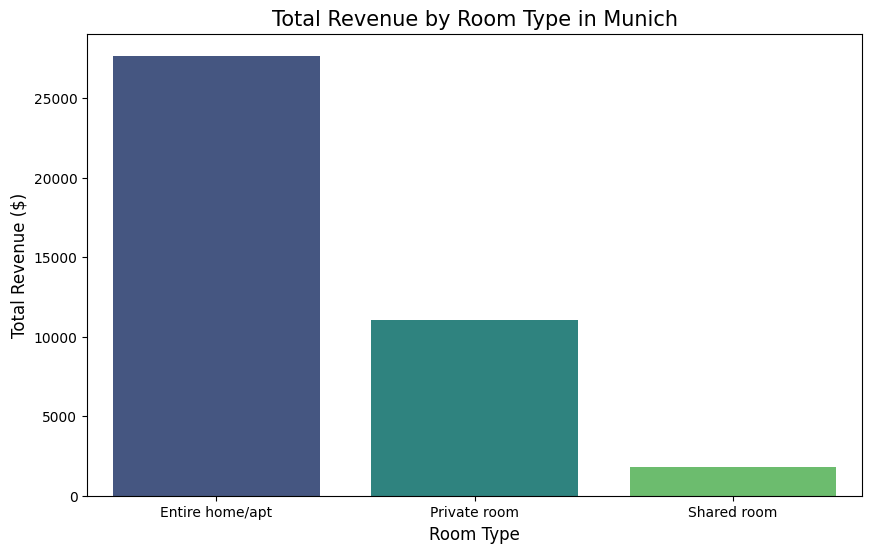

In [38]:
room_type_summary = munich_revenue[munich_revenue['room_type']!='Hotel room'].groupby('room_type', as_index=False)['revenue'].sum()

room_type_summary = room_type_summary.sort_values(by='revenue', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=room_type_summary, x='room_type', y='revenue', palette='viridis')

plt.title('Total Revenue by Room Type in Munich', fontsize=15)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

plt.show()

/var/folders/3b/rk4wlpz91b550937x0t31krc0000gn/T/ipykernel_4221/3322346735.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=room_type_summary, x='neighbourhood', y='revenue', palette='viridis')


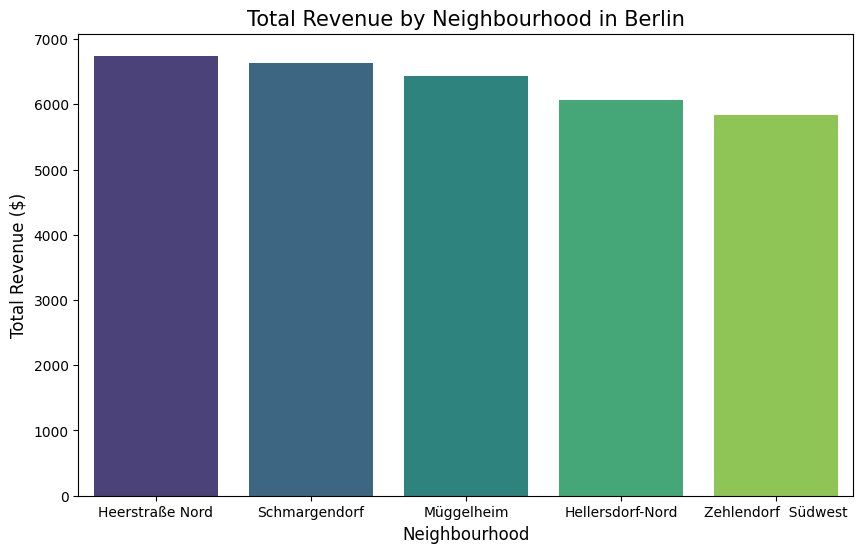

In [39]:
room_type_summary = berlin_revenue[berlin_revenue['room_type']!='Hotel room'].head(5).groupby('neighbourhood', as_index=False)['revenue'].sum()

room_type_summary = room_type_summary.sort_values(by='revenue', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=room_type_summary, x='neighbourhood', y='revenue', palette='viridis')

plt.title('Total Revenue by Neighbourhood in Berlin', fontsize=15)
plt.xlabel('Neighbourhood', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

plt.show()

/var/folders/3b/rk4wlpz91b550937x0t31krc0000gn/T/ipykernel_4221/639479756.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=room_type_summary, x='neighbourhood', y='revenue', palette='viridis')


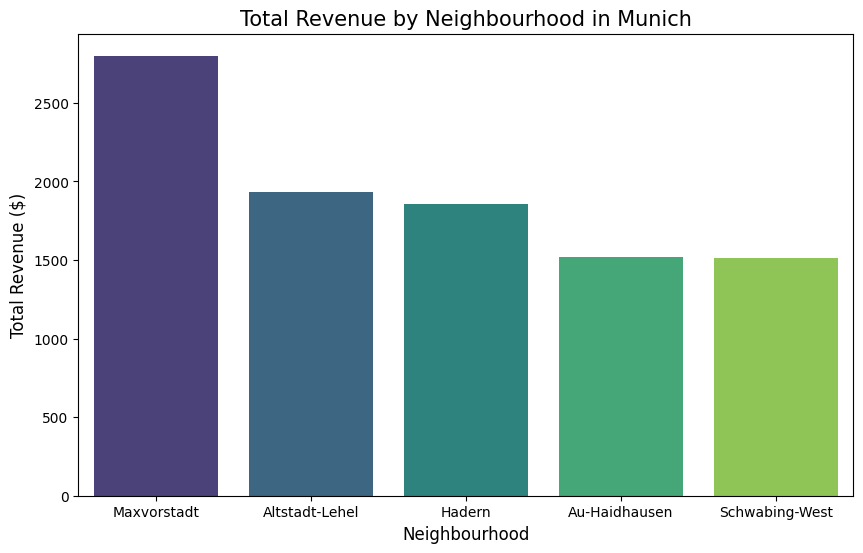

In [40]:
room_type_summary = munich_revenue[munich_revenue['room_type']!='Hotel room'].head(5).groupby('neighbourhood', as_index=False)['revenue'].sum()

room_type_summary = room_type_summary.sort_values(by='revenue', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=room_type_summary, x='neighbourhood', y='revenue', palette='viridis')

plt.title('Total Revenue by Neighbourhood in Munich', fontsize=15)
plt.xlabel('Neighbourhood', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

plt.show()

In [41]:
df_berlin = df3[
    (df3['city'] == 'Berlin') & 
    (df3['room_type'] == 'Entire home/apt') &
    (df3['price'] < 1000)].copy()

berlin_revenue = df_berlin.groupby(['neighbourhood', 'room_type'], as_index=False)['revenue'].mean()

berlin_revenue = berlin_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)
berlin_revenue["revenue"] = berlin_revenue["revenue"].round(2)
berlin_revenue

,neighbourhood,room_type,revenue
0,Heerstraße Nord,Entire home/apt,6745.50
1,Schmargendorf,Entire home/apt,6637.45
2,Zehlendorf Südwest,Entire home/apt,5844.14
3,Zehlendorf Nord,Entire home/apt,5795.00
4,Grunewald,Entire home/apt,5690.20
...,...,...,...
131,Falkenhagener Feld,Entire home/apt,240.50
132,MV 2,Entire home/apt,198.00
133,Altstadt-Kietz,Entire home/apt,166.33
134,Allende-Viertel,Entire home/apt,50.00


In [42]:
df_berlin = df3[
    (df3['city'] == 'Berlin') & 
    (df3['room_type'] == 'Private room') &
    (df3['price'] < 1000)].copy()

berlin_revenue = df_berlin.groupby(['neighbourhood', 'room_type'], as_index=False)['revenue'].mean()

berlin_revenue = berlin_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)
berlin_revenue["revenue"] = berlin_revenue["revenue"].round(2)
berlin_revenue

,neighbourhood,room_type,revenue
0,Müggelheim,Private room,6440.00
1,Hellersdorf-Nord,Private room,6067.33
2,Wilhelmstadt,Private room,5194.00
3,Lankwitz,Private room,4305.00
4,Schmargendorf,Private room,4283.00
...,...,...,...
127,West 1,Private room,71.00
128,Zehlendorf Südwest,Private room,62.00
129,Weißensee Ost,Private room,53.00
130,Altglienicke,Private room,49.50


In [43]:
df_berlin = df3[
    (df3['city'] == 'Berlin') & 
    (df3['room_type'] == 'Shared room') &
    (df3['price'] < 1000)].copy()

berlin_revenue = df_berlin.groupby(['neighbourhood', 'room_type'], as_index=False)['revenue'].mean()

berlin_revenue = berlin_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)
berlin_revenue["revenue"] = berlin_revenue["revenue"].round(2)
berlin_revenue

,neighbourhood,room_type,revenue
0,Adlershof,Shared room,4140.00
1,nördliche Luisenstadt,Shared room,396.00
2,Moabit West,Shared room,363.67
3,Moabit Ost,Shared room,106.50
4,Niederschöneweide,Shared room,66.00
5,südliche Luisenstadt,Shared room,62.67
6,Blankenfelde/Niederschönhausen,Shared room,59.00
7,Karl-Marx-Allee-Süd,Shared room,55.82
8,Prenzlauer Berg Südwest,Shared room,55.25
9,Parkviertel,Shared room,55.00


In [44]:
df_berlin = df3[
    (df3['city'] == 'Berlin') & 
    (df3['room_type'] == 'Hotel room') &
    (df3['price'] < 1000)].copy()

berlin_revenue = df_berlin.groupby(['neighbourhood', 'room_type'], as_index=False)['revenue'].mean()

berlin_revenue = berlin_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)
berlin_revenue["revenue"] = berlin_revenue["revenue"].round(2)
berlin_revenue

,neighbourhood,room_type,revenue
0,Westend,Hotel room,74520.00
1,Karlshorst,Hotel room,1191.00
2,Prenzlauer Berg Ost,Hotel room,1097.00
3,Otto-Suhr-Allee,Hotel room,980.80
4,Wilhelmstadt,Hotel room,528.00
5,Prenzlauer Berg Südwest,Hotel room,421.17
6,Spandau Mitte,Hotel room,388.33
7,Frankfurter Allee Nord,Hotel room,334.00
8,Tiergarten Süd,Hotel room,264.50
9,Halensee,Hotel room,260.25


In [45]:
df_munich = df3[
    (df3['city'] == 'Munich') & 
    (df3['room_type'] == 'Entire home/apt') &
    (df3['price'] < 1000)].copy()

munich_revenue = df_munich.groupby(['neighbourhood', 'room_type'], as_index=False)['revenue'].mean()

munich_revenue = munich_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)
munich_revenue["revenue"] = munich_revenue["revenue"].round(2)
munich_revenue

,neighbourhood,room_type,revenue
0,Altstadt-Lehel,Entire home/apt,1929.83
1,Hadern,Entire home/apt,1856.18
2,Au-Haidhausen,Entire home/apt,1519.79
3,Schwabing-West,Entire home/apt,1512.70
4,Pasing-Obermenzing,Entire home/apt,1507.75
5,Neuhausen-Nymphenburg,Entire home/apt,1402.23
6,Maxvorstadt,Entire home/apt,1367.87
7,Ludwigsvorstadt-Isarvorstadt,Entire home/apt,1249.89
8,Untergiesing-Harlaching,Entire home/apt,1240.63
9,Milbertshofen-Am Hart,Entire home/apt,1221.41


In [46]:
df_munich = df3[
    (df3['city'] == 'Munich') & 
    (df3['room_type'] == 'Private room') &
    (df3['price'] < 1000)].copy()

munich_revenue = df_munich.groupby(['neighbourhood', 'room_type'], as_index=False)['revenue'].mean()

munich_revenue = munich_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)
munich_revenue["revenue"] = munich_revenue["revenue"].round(2)
munich_revenue

,neighbourhood,room_type,revenue
0,Maxvorstadt,Private room,2799.67
1,Altstadt-Lehel,Private room,614.10
2,Thalkirchen-Obersendling-Forstenried-Fürstenri...,Private room,504.36
3,Neuhausen-Nymphenburg,Private room,475.78
4,Untergiesing-Harlaching,Private room,458.46
5,Schwabing-West,Private room,448.52
6,Laim,Private room,410.03
7,Schwabing-Freimann,Private room,408.48
8,Ludwigsvorstadt-Isarvorstadt,Private room,383.18
9,Tudering-Riem,Private room,383.01


In [47]:
df_munich = df3[
    (df3['city'] == 'Munich') & 
    (df3['room_type'] == 'Shared room') &
    (df3['price'] < 1000)].copy()

munich_revenue = df_munich.groupby(['neighbourhood', 'room_type'], as_index=False)['revenue'].mean()

munich_revenue = munich_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)
munich_revenue["revenue"] = munich_revenue["revenue"].round(2)
munich_revenue

,neighbourhood,room_type,revenue
0,Ludwigsvorstadt-Isarvorstadt,Shared room,343.00
1,Sendling,Shared room,290.00
2,Sendling-Westpark,Shared room,262.60
3,Berg am Laim,Shared room,210.00
4,Schwabing-Freimann,Shared room,156.50
5,Allach-Untermenzing,Shared room,140.00
6,Tudering-Riem,Shared room,94.44
7,Thalkirchen-Obersendling-Forstenried-Fürstenri...,Shared room,84.00
8,Bogenhausen,Shared room,64.00
9,Schwabing-West,Shared room,63.00


In [48]:
df_munich = df3[
    (df3['city'] == 'Munich') & 
    (df3['room_type'] == 'Hotel room') &
    (df3['price'] < 1000)].copy()

munich_revenue = df_munich.groupby(['neighbourhood', 'room_type'], as_index=False)['revenue'].mean()

munich_revenue = munich_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)
munich_revenue["revenue"] = munich_revenue["revenue"].round(2)
munich_revenue

,neighbourhood,room_type,revenue
0,Maxvorstadt,Hotel room,301.00
1,Tudering-Riem,Hotel room,299.00
2,Neuhausen-Nymphenburg,Hotel room,240.67
3,Milbertshofen-Am Hart,Hotel room,179.00
4,Ludwigsvorstadt-Isarvorstadt,Hotel room,88.00


“Revenue is approximated using price × minimum nights, which reflects the minimum transaction value rather than actual realized revenue. A more accurate estimate would require occupancy or booking frequency data.”

In [49]:
desc_table = df3.groupby('city').agg({
    'price': ['mean'],
    'revenue': ['mean'],
    'minimum_nights': ['mean']
})

# Flatten column names
desc_table.columns = [
    'Average Price (€)',
    'Average Revenue (€)',
    'Average Minimum Nights']

# Round values and reshape
desc_table = desc_table.stack(level=0)   # move variables to rows
desc_table = desc_table.unstack(level=0) # cities become columns
desc_table = desc_table.round(0)
desc_table

# Display with title
print("Descriptive Statistics")
desc_table

Descriptive Statistics


city,Berlin,Munich
Average Price (€),202.0,264.0
Average Revenue (€),2775.0,1418.0
Average Minimum Nights,27.0,6.0


In [50]:
import pandas as pd
neigh_count = df3.groupby('city')['neighbourhood'].nunique()
room_count = df3.groupby(['city', 'room_type']).size().unstack(fill_value=0)
room_count = room_count.drop(columns=["Hotel room"], errors="ignore")
neigh_count = neigh_count.to_frame(name='Neighbourhoods')
count_table = pd.concat([neigh_count.T, room_count.T], axis=0)
count_table

city,Berlin,Munich
Neighbourhoods,138,25
Entire home/apt,6791,3697
Private room,2194,1842
Shared room,97,25
